**Task 01:**

2x2 Scaling Matrix:
[[3. 0.]
 [0. 3.]]

Original size : 474 x 841
Scaled size   : 1422 x 2523
Offset to keep centered — X: 474.0, Y: 841.0


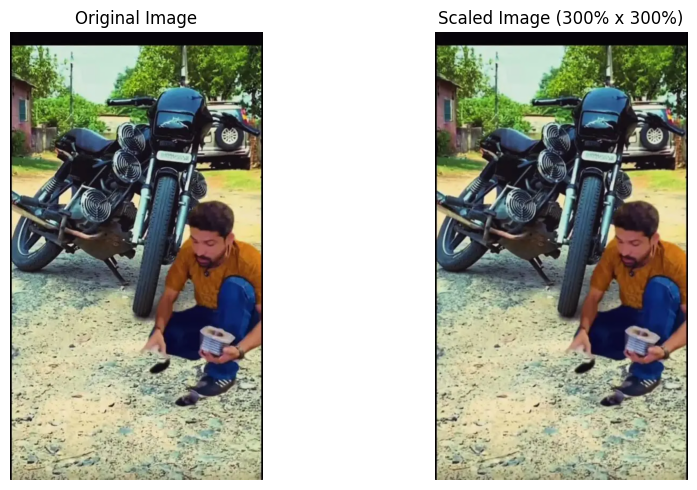

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/image.webp")

if image is None:
    print("Error: Image could not be loaded.")
else:
    # --- Build 2x2 Scaling Matrix manually ---
    scale_x = 3.0  # 300% on x-axis
    scale_y = 3.0  # 300% on y-axis

    # Manual 2x2 scaling matrix
    scaling_matrix = np.array([
        [scale_x, 0],
        [0,       scale_y]
    ])
    print("2x2 Scaling Matrix:")
    print(scaling_matrix)

    # --- Apply scaling using cv2.resize (equivalent to applying the matrix) ---
    scaled = cv2.resize(image, None, fx=scale_x, fy=scale_y, interpolation=cv2.INTER_LINEAR)

    # --- Calculate centering offsets ---
    orig_h, orig_w = image.shape[:2]
    scaled_h, scaled_w = scaled.shape[:2]

    # How much the image grew
    offset_x = (scaled_w - orig_w) / 2
    offset_y = (scaled_h - orig_h) / 2

    print(f"\nOriginal size : {orig_w} x {orig_h}")
    print(f"Scaled size   : {scaled_w} x {scaled_h}")
    print(f"Offset to keep centered — X: {offset_x}, Y: {offset_y}")

    # --- Convert BGR to RGB for display ---
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    scaled_rgb = cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB)

    # --- Plot side by side ---
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(scaled_rgb)
    plt.title("Scaled Image (300% x 300%)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Task02:**

2x2 Rotation Matrix (45°):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Original size : 474 x 841
New size after rotation: 929 x 929


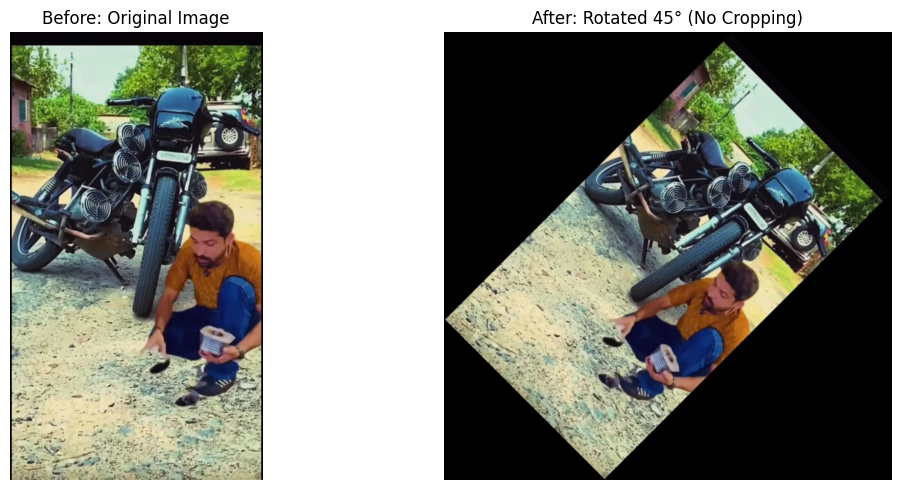

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/image.webp")

if image is None:
    print("Error: image.jpg not found")
else:
    height, width = image.shape[:2]

    # --- Manual 2x2 Rotation Matrix (45 degrees) ---
    angle_deg = 45
    angle_rad = np.deg2rad(angle_deg)  # Convert to radians

    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)

    # Manual 2x2 rotation matrix
    rotation_matrix_2x2 = np.array([
        [cos_a, -sin_a],
        [sin_a,  cos_a]
    ])

    print("2x2 Rotation Matrix (45°):")
    print(rotation_matrix_2x2)

    # --- Manually Calculate New Dimensions (so corners don't get chopped) ---
    # New width and height after rotation
    new_width  = int(abs(width * cos_a) + abs(height * sin_a))
    new_height = int(abs(width * sin_a) + abs(height * cos_a))

    print(f"\nOriginal size : {width} x {height}")
    print(f"New size after rotation: {new_width} x {new_height}")

    # --- Build Full 2x3 Affine Matrix with centering offset ---
    # Shift so the rotated image stays centered in the new canvas
    center_x = width / 2
    center_y = height / 2

    offset_x = (new_width / 2) - (cos_a * center_x - sin_a * center_y)
    offset_y = (new_height / 2) - (sin_a * center_x + cos_a * center_y)

    # Full affine matrix (2x3): rotation + translation
    M = np.array([
        [cos_a, -sin_a, offset_x],
        [sin_a,  cos_a, offset_y]
    ])

    # --- Apply rotation with new canvas size ---
    rotated = cv2.warpAffine(image, M, (new_width, new_height))

    # --- Convert BGR -> RGB for display ---
    image_rgb  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

    # --- Display ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Before: Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(rotated_rgb)
    plt.title("After: Rotated 45° (No Cropping)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Task03**

2x2 Shear Matrix:
[[ 1.  -0.5]
 [ 0.   1. ]]

Original size : 474 x 841
New width after shear correction: 894 x 841

Full 2x3 Affine Matrix applied:
[[  1.   -0.5 420.5]
 [  0.    1.    0. ]]


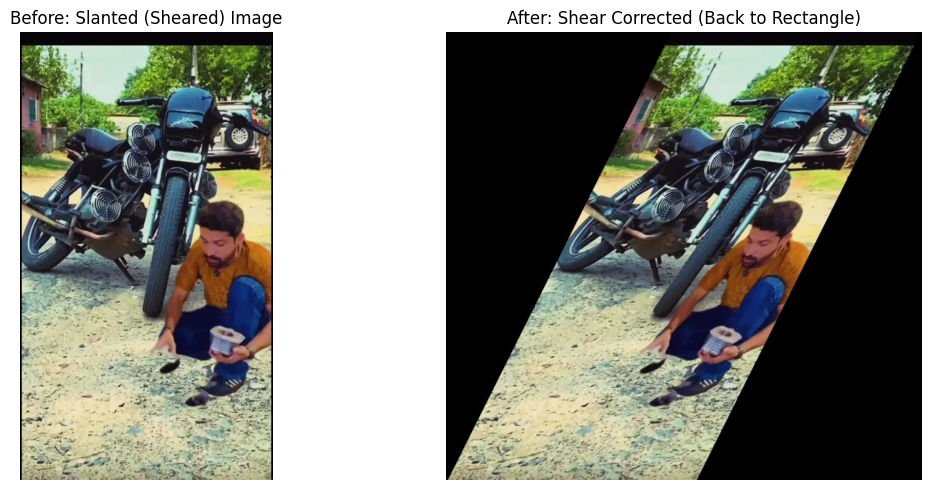

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/image.webp")

if image is None:
    print("Error: image.jpg not found")
else:
    height, width = image.shape[:2]

    # --- Manual 2x2 Shear Matrix ---
    # Negative kx to "push back" the slant (correct a right-leaning shear)
    kx = -0.5  # shear factor: negative = push left to straighten

    # Manual 2x2 shear matrix
    shear_matrix_2x2 = np.array([
        [1,  kx],
        [0,   1]
    ])

    print("2x2 Shear Matrix:")
    print(shear_matrix_2x2)

    # --- Calculate new canvas width so nothing gets chopped ---
    # When kx is negative, left side shifts; we need extra space on left
    new_width = int(width + abs(kx) * height)

    print(f"\nOriginal size : {width} x {height}")
    print(f"New width after shear correction: {new_width} x {height}")

    # --- Build full 2x3 Affine Matrix ---
    # If kx is negative, add an x-offset to shift image back into frame
    offset_x = abs(kx) * height if kx < 0 else 0

    M = np.float32([
        [1,  kx, offset_x],
        [0,   1,        0]
    ])

    print(f"\nFull 2x3 Affine Matrix applied:")
    print(M)

    # --- Apply shear correction ---
    corrected = cv2.warpAffine(image, M, (new_width, height))

    # --- Convert BGR -> RGB ---
    image_rgb    = cv2.cvtColor(image,     cv2.COLOR_BGR2RGB)
    corrected_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    # --- Display ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Before: Slanted (Sheared) Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(corrected_rgb)
    plt.title("After: Shear Corrected (Back to Rectangle)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Task04**

3x3 Translation Matrix:
[[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]

Original size  : 474 x 841
Translation    : tx = +150 (right), ty = +80 (down)
Map was hidden : 150px left, 80px up → now restored to frame


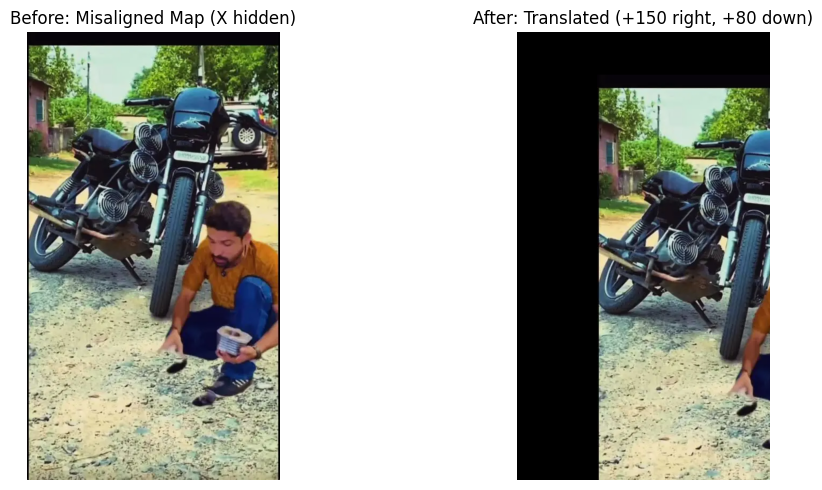

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/image.webp")

if image is None:
    print("Error: image.jpg not found")
else:
    height, width = image.shape[:2]

    # --- The map is hidden: 150px to the LEFT and 80px UP ---
    # To bring it BACK into view, we translate: +150 right, +80 down
    tx = 150   # shift right to recover hidden left side
    ty = 80    # shift down to recover hidden top side

    # --- 3x3 Homogeneous Translation Matrix ---
    translation_matrix_3x3 = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0,  1]
    ], dtype=np.float32)

    print("3x3 Translation Matrix:")
    print(translation_matrix_3x3)

    print(f"\nOriginal size  : {width} x {height}")
    print(f"Translation    : tx = +{tx} (right), ty = +{ty} (down)")
    print(f"Map was hidden : 150px left, 80px up → now restored to frame")

    # --- Extract 2x3 portion for cv2.warpAffine ---
    # (OpenCV uses 2x3, but we built the full 3x3 as required by task)
    M = translation_matrix_3x3[:2, :]  # Take first 2 rows from 3x3

    # --- Apply translation ---
    translated = cv2.warpAffine(image, M, (width, height))

    # --- Convert BGR -> RGB ---
    image_rgb     = cv2.cvtColor(image,      cv2.COLOR_BGR2RGB)
    translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

    # --- Display ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Before: Misaligned Map (X hidden)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(translated_rgb)
    plt.title("After: Translated (+150 right, +80 down)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()